In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

import joblib

In [7]:
file_path = '/Users/lincu/Documents/Big Data Project/online_shoppers_intention.csv'

df = pd.read_csv(file_path)
print(f"Loaded: {'online_shoppers_intention'} with shape {df.shape}")
display(df.head())

Loaded: online_shoppers_intention with shape (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Revenue
False    10422
True      1908
Name: count, dtype: int64


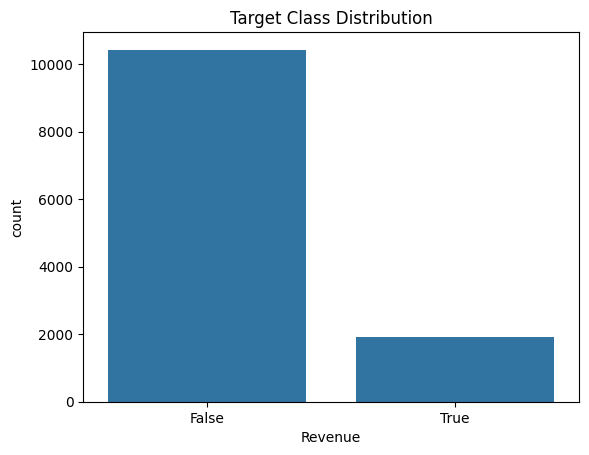

In [8]:
print(df["Revenue"].value_counts())

sns.countplot(x="Revenue", data=df)
plt.title("Target Class Distribution")
plt.show()

In [9]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [10]:
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

In [11]:
df = pd.get_dummies(df, columns=["Month"], drop_first=True)

In [12]:
df = pd.get_dummies(df, columns=["VisitorType"], drop_first=True)

Select Features and Target Variables

In [13]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
%pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

DECISION TREE

In [43]:
#Train model

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_balanced, y_train_balanced)

DecisionTreeClassifier(random_state=42)

In [44]:
#predict

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [45]:
#Evaluate

print("Decision Tree Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Confusion Matrix:
 [[1859  225]
 [ 151  231]]
Accuracy: 0.8475263584752636
Precision: 0.506578947368421
Recall: 0.6047120418848168
F1 Score: 0.5513126491646778
ROC-AUC: 0.7483732954145772
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2084
           1       0.51      0.60      0.55       382

    accuracy                           0.85      2466
   macro avg       0.72      0.75      0.73      2466
weighted avg       0.86      0.85      0.85      2466



RANDOM FOREST

In [46]:
#Train Model

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

In [47]:
#Predict

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [48]:
#Evaluate

print("Random Forest Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Confusion Matrix:
 [[1924  160]
 [ 116  266]]
Accuracy: 0.8880778588807786
Precision: 0.6244131455399061
Recall: 0.6963350785340314
F1 Score: 0.6584158415841584
ROC-AUC: 0.9200703942277738
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2084
           1       0.62      0.70      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.81      0.80      2466
weighted avg       0.89      0.89      0.89      2466



K-NEAREST NEIGHBORS (KNN)

In [51]:
#Train Model

knn = KNeighborsClassifier()
knn.fit(X_train_balanced, y_train_balanced)

KNeighborsClassifier()

In [52]:
#Predict

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [53]:
#Evaluate

print("KNN Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print(classification_report(y_test, y_pred_knn))

KNN Results
Confusion Matrix:
 [[2080    4]
 [ 381    1]]
Accuracy: 0.8438767234387672
Precision: 0.2
Recall: 0.002617801047120419
F1 Score: 0.00516795865633075
ROC-AUC: 0.5016562239350423
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2084
           1       0.20      0.00      0.01       382

    accuracy                           0.84      2466
   macro avg       0.52      0.50      0.46      2466
weighted avg       0.75      0.84      0.77      2466



NAIVE BAYES

In [54]:
#Train Model

nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)

GaussianNB()

In [55]:
#Predict

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

In [56]:
#Evaluate

print("Naive Bayes Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results
Confusion Matrix:
 [[1635  449]
 [ 128  254]]
Accuracy: 0.7660178426601785
Precision: 0.3613086770981508
Recall: 0.6649214659685864
F1 Score: 0.4682027649769585
ROC-AUC: 0.7808621659916993
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      2084
           1       0.36      0.66      0.47       382

    accuracy                           0.77      2466
   macro avg       0.64      0.72      0.66      2466
weighted avg       0.84      0.77      0.79      2466



SUPPORT VECTOR MACHINE (SVM)

In [58]:
#Train Model

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_balanced, y_train_balanced)

SVC(probability=True, random_state=42)

In [59]:
#Predict

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [60]:
#Evaluate

print("SVM Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print(classification_report(y_test, y_pred_svm))

SVM Results
Confusion Matrix:
 [[2084    0]
 [ 382    0]]
Accuracy: 0.8450932684509327
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.816378340083006
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2084
           1       0.00      0.00      0.00       382

    accuracy                           0.85      2466
   macro avg       0.42      0.50      0.46      2466
weighted avg       0.71      0.85      0.77      2466



c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

Final Step — Create Comparison Table

In [61]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "KNN", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm)
    ]
})

comparison.sort_values(by="F1-Score", ascending=False)

c:\Users\lincu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.888078,0.624413,0.696335,0.658416
0,Decision Tree,0.847526,0.506579,0.604712,0.551313
3,Naive Bayes,0.766018,0.361309,0.664921,0.468203
2,KNN,0.843877,0.200000,0.002618,0.005168
4,SVM,0.845093,0.000000,0.000000,0.000000


In [62]:
best_model_name = comparison.loc[comparison["F1-Score"].idxmax(), "Model"]
print("Best Model:", best_model_name)

Best Model: Random Forest


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_balanced, y_train_balanced)

print("Best Parameters:", grid_search.best_params_)

KeyboardInterrupt: 

Evaluate Tuned Model

In [34]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Tuned Random Forest Results
Confusion Matrix:
 [[2004   80]
 [ 170  212]]
Accuracy: 0.8986212489862125
Precision: 0.726027397260274
Recall: 0.5549738219895288
F1 Score: 0.629080118694362
ROC-AUC: 0.9220833626433259


In [35]:
import joblib

joblib.dump(best_rf, "purchase_intention_model.pkl")

['purchase_intention_model.pkl']

In [36]:
def recommend_action(prediction):

    if prediction == 1:
        return "Customer likely to purchase. Recommend bundle deals or premium offers."

    else:
        return "Customer unlikely to purchase. Offer discount coupons or promotions."

In [37]:
sample_pred = best_rf.predict(X_test.iloc[[0]])[0]
recommend_action(sample_pred)

'Customer unlikely to purchase. Offer discount coupons or promotions.'

In [38]:
joblib.dump((best_rf, X.columns.tolist()), "purchase_intention_model.pkl")

['purchase_intention_model.pkl']